# **Deep Learning Concepts**

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras import models, layers


df = pd.read_csv(r'D:\Codes\MachineLearning\Datasets\study-hours.csv')
df

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30
...,...,...
91,5.8,60
92,4.4,44
93,6.1,63
94,3.7,37


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   96 non-null     float64
 1   Scores  96 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 1.6 KB


In [38]:
X = df[['Hours']].values
y = df['Scores'].values

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=54)


In [40]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


y_train_scaled = scaler.fit_transform(y_train.reshape(-1,1))
y_test_scaled = scaler.transform(y_test.reshape(-1,1))


In [41]:
model = models.Sequential([
    layers.Dense(16, activation='relu', input_shape=(1,)),
    layers.Dense(8, activation='relu'),
    layers.Dense(1)
])

d:\Codes\.venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


In [45]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [48]:
history = model.fit(
    X_train, 
    y_train,
    validation_data=(X_test, y_test),
    epochs=5000,
    verbose=1,
    callbacks=[early_stop]

)

Epoch 1/5000


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 1292.6995 - mae: 29.9494 - val_loss: 1555.5784 - val_mae: 34.6814
Epoch 2/5000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 1268.5779 - mae: 29.6102 - val_loss: 1527.2633 - val_mae: 34.3076
Epoch 3/5000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 1246.2251 - mae: 29.2846 - val_loss: 1499.0381 - val_mae: 33.9312
Epoch 4/5000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 1221.3102 - mae: 28.9407 - val_loss: 1471.6702 - val_mae: 33.5624
Epoch 5/5000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 1198.4907 - mae: 28.6066 - val_loss: 1444.2593 - val_mae: 33.1891
Epoch 6/5000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 1175.9493 - mae: 28.2789 - val_loss: 1417.0375 - val_mae: 32.8145
Epoch 7/5000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 1152.2106 - mae: 27.9466 - val_loss: 1390.5590 - val_mae: 32.4681
Epoch 8/5000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1130.4972 - mae: 27.6192 - val_loss: 1364.0554 - val_mae: 32.1213
Epoch 9/5000


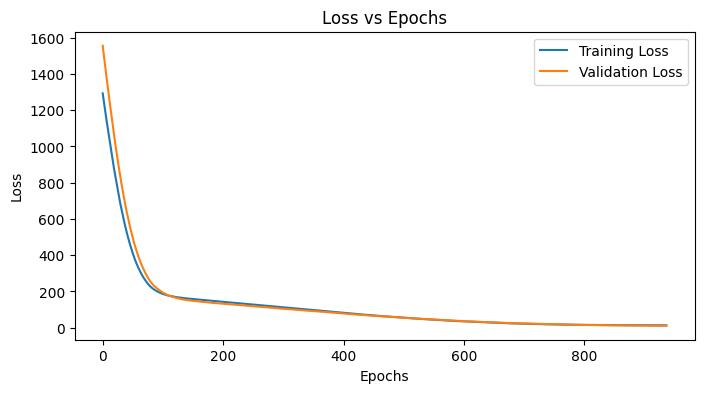

In [49]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

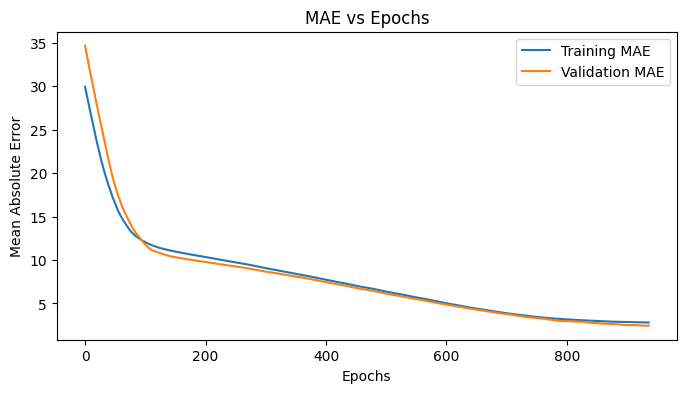

In [51]:
plt.figure(figsize=(8,4))
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('MAE vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()


In [52]:
print(history.history.keys())


dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])


In [ ]:
loss, mae = model.evaluate(X_test, y_test)
print("Test MAE:", mae)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 10.6413 - mae: 2.4331
Test MAE: 2.433081865310669


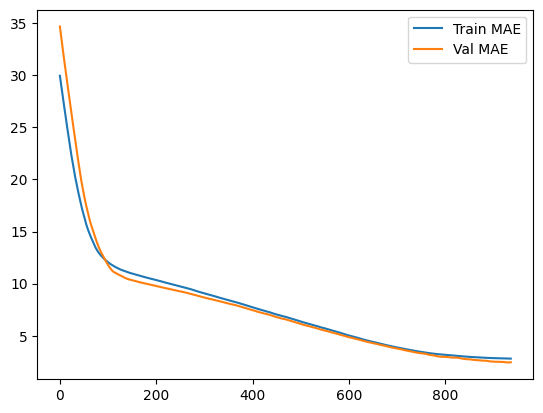

In [54]:
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.legend()
plt.show()
